# Computer Vision Assignment 2

## Imports

In [1]:
from __future__ import print_function

# Core deep learning framework
import tensorflow as tf
import keras

# Keras model and layer imports
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Rescaling, BatchNormalization

# Optimisers
from keras.optimizers import RMSprop, Adam

# Plotting and numerical operations
import matplotlib.pyplot as plt
import numpy as np

## Configuration

In [3]:
# Training parameters
batch_size = 12
epochs = 8

# Image dimensions
img_width = 128
img_height = 128
img_channels = 3

# Controls whether the model is trained or loaded from disk
fit = True

# Dataset paths
train_dir = 'data/chest_xray/train'
test_dir  = 'data/chest_xray/test'

## Load Datasets

In [4]:
# Load training and validation datasets from directory
# 80% training, 20% validation split
train_ds, val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    seed=123,
    validation_split=0.2,
    subset='both',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    labels='inferred',
    shuffle=True)

# Load test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    seed=None,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    labels='inferred',
    shuffle=True)

# Infer class names from subfolder names
class_names = train_ds.class_names
num_classes = len(class_names)
print('Class Names:', class_names)
print('Number of Classes:', num_classes)

Found 5419 files belonging to 3 classes.
Using 4336 files for training.
Using 1083 files for validation.
Found 437 files belonging to 3 classes.
Class Names: ['BACTERIAL', 'NORMAL', 'VIRAL']
Number of Classes: 3


## Visualise Sample Images

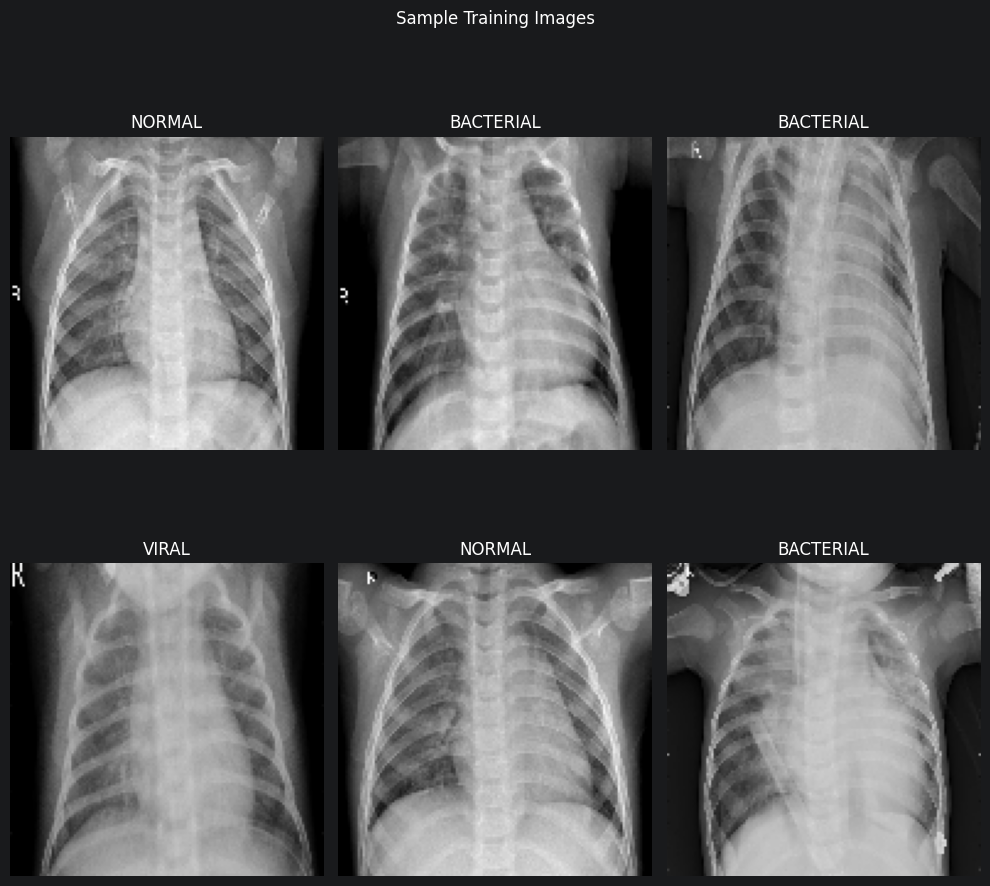

In [6]:
# Display a sample of images from the training dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(2):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.savefig('results/plots/step1_sample_images.png')
plt.show()

## Build the Model

In [10]:
# Build the baseline CNN model
model = tf.keras.models.Sequential([
    # Define input shape explicitly
    tf.keras.Input(shape=(img_height, img_width, img_channels)),
    # Normalise pixel values from [0, 255] to [0, 1]
    Rescaling(1.0/255),
    # Convolutional layers for feature extraction
    Conv2D(16, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    # Flatten multidimensional output into a single dimension
    Flatten(),
    # Fully connected layers for classification
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,227,651 (12.31 MB)

 Trainable params: 3,227,651 (12.31 MB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

In [12]:
import time

# Save the best model during training
save_callback = tf.keras.callbacks.ModelCheckpoint(
    'results/baseline.keras',
    save_freq='epoch',
    save_best_only=True
)

# Record training time
start_time = time.time()

if fit:
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        callbacks=[save_callback],
        epochs=epochs
    )
else:
    # Load saved model instead of retraining
    model = tf.keras.models.load_model('results/baseline.keras')

elapsed = time.time() - start_time
print(f'Training time: {elapsed/60:.1f} minutes')

Epoch 1/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7108 - loss: 0.6724 - val_accuracy: 0.7285 - val_loss: 0.6231
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7867 - loss: 0.5216 - val_accuracy: 0.7664 - val_loss: 0.5470
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8005 - loss: 0.4726 - val_accuracy: 0.7747 - val_loss: 0.5002
Epoch 4/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8247 - loss: 0.4249 - val_accuracy: 0.7747 - val_loss: 0.5374
Epoch 5/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8314 - loss: 0.3892 - val_accuracy: 0.7802 - val_loss: 0.5365
Epoch 6/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8503 - loss: 0.3586 - val_accuracy: 0.7765 - val_loss: 0.5484
Epoch 7/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8741 - loss: 0.3037 - val_accuracy: 0.7830 - val_loss: 0.5782
Epoch 8/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8997 - loss: 0.2454 - val_accuracy: 0.

## Evaluate Model on Test Set

In [13]:
# Evaluate the trained model on the test set
score = model.evaluate(test_ds)
print(f'Test Loss:     {score[0]:.4f}')
print(f'Test Accuracy: {score[1]*100:.2f}%')

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7551 - loss: 0.7050
Test Loss:     0.7050
Test Accuracy: 75.51%


## Plot Training History

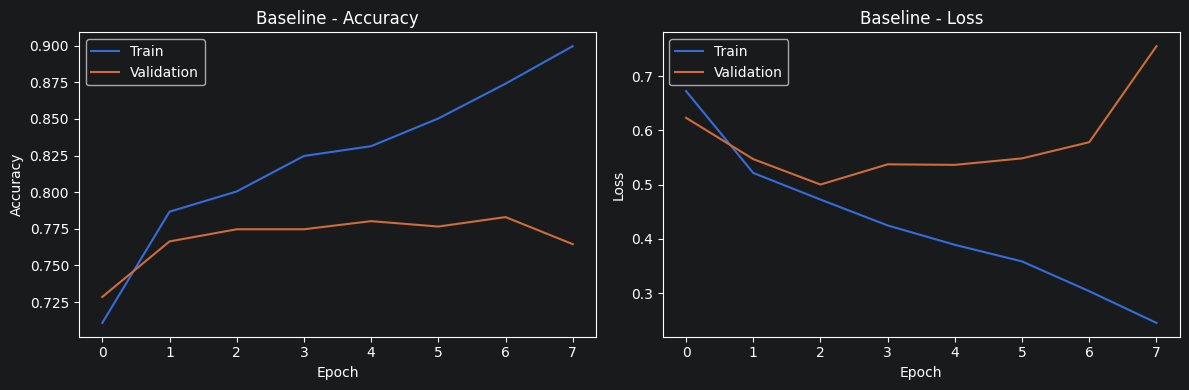

In [14]:
# Plot training and validation accuracy and loss over epochs
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Baseline - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Baseline - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('results/plots/step1_training_history.png')
plt.show()

## Dataset Analysis (Class Distribution)

Training set class distribution:
  BACTERIAL: 2087 images
  VIRAL: 1084 images
  NORMAL: 1165 images


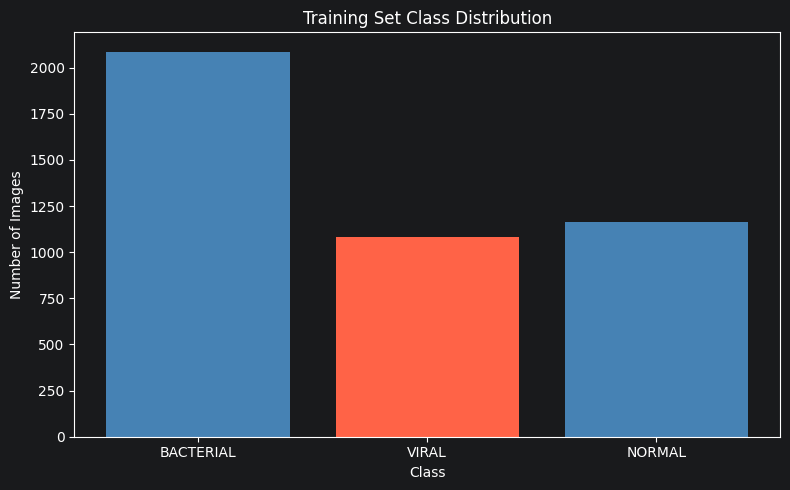

In [15]:
# Count the number of images per class in the training set
class_counts = {}
for images, labels in train_ds.unbatch():
    label = class_names[labels.numpy()]
    class_counts[label] = class_counts.get(label, 0) + 1

print("Training set class distribution:")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count} images")

# Plot class distribution
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values(), color=['steelblue', 'tomato'])
plt.title('Training Set Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.savefig('results/plots/step2_class_distribution.png')
plt.show()

## Compute Class Weights

In [16]:
from sklearn.utils.class_weight import compute_class_weight

# Collect all labels from the training set
all_labels = []
for images, labels in train_ds.unbatch():
    all_labels.append(labels.numpy())

# Compute class weights to address class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:")
for i, weight in class_weight_dict.items():
    print(f"  {class_names[i]}: {weight:.4f}")

Class weights:
  BACTERIAL: 0.6925
  NORMAL: 1.2406
  VIRAL: 1.3333


## Improving Model by fixing Overfitting

In [17]:
# Improved model using GlobalAveragePooling2D instead of Flatten
# to reduce the number of parameters and combat overfitting
model_v2 = tf.keras.models.Sequential([
    tf.keras.Input(shape=(img_height, img_width, img_channels)),
    # Normalise pixel values from [0, 255] to [0, 1]
    Rescaling(1.0/255),
    # Convolutional layers for feature extraction
    Conv2D(16, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    # GlobalAveragePooling2D replaces Flatten - averages each feature map
    # into a single value, drastically reducing parameters
    tf.keras.layers.GlobalAveragePooling2D(),
    # Fully connected layers with increased dropout to reduce overfitting
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_v2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

model_v2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,291 (126.14 KB)

 Trainable params: 32,291 (126.14 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Improved Model

In [18]:
# Save the best improved model during training
save_callback_v2 = tf.keras.callbacks.ModelCheckpoint(
    'results/improved.keras',
    save_freq='epoch',
    save_best_only=True
)

# Early stopping to prevent overfitting
earlystop_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5
)

start_time = time.time()

history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    class_weight=class_weight_dict,
    callbacks=[save_callback_v2, earlystop_callback]
)

elapsed = time.time() - start_time
print(f'Training time: {elapsed/60:.1f} minutes')

Epoch 1/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3997 - loss: 1.0621 - val_accuracy: 0.5032 - val_loss: 1.0438
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6056 - loss: 0.8962 - val_accuracy: 0.6214 - val_loss: 0.8448
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6580 - loss: 0.8098 - val_accuracy: 0.6907 - val_loss: 0.7602
Epoch 4/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6674 - loss: 0.7688 - val_accuracy: 0.6990 - val_loss: 0.7258
Epoch 5/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6762 - loss: 0.7488 - val_accuracy: 0.7036 - val_loss: 0.7133
Epoch 6/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6875 - loss: 0.7174 - val_accuracy: 0.7101 - val_loss: 0.7163
Epoch 7/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6917 - loss: 0.7025 - val_accuracy: 0.7165 - val_loss: 0.6656
Epoch 8/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7002 - loss: 0.6831 - val_accuracy: 0.7248 - v

## Evaluate Improved Model on Test Set

In [19]:
# Evaluate the improved model on the test set
score_v2 = model_v2.evaluate(test_ds)
print(f'Baseline Test Accuracy:  75.51%')
print(f'Improved Test Accuracy:  {score_v2[1]*100:.2f}%')

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7048 - loss: 0.6676
Baseline Test Accuracy:  75.51%
Improved Test Accuracy:  70.48%


## Plot Improved Model Training History

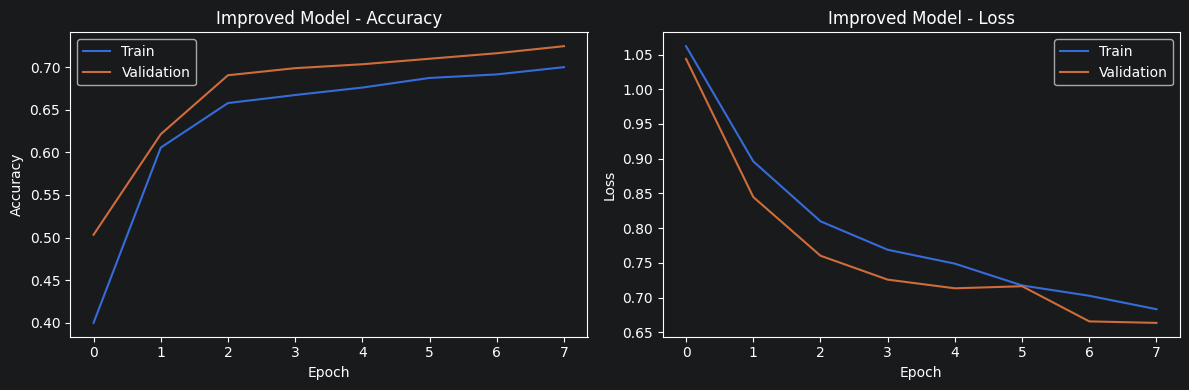

In [20]:
# Plot training and validation accuracy and loss for improved model
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_v2.history['accuracy'], label='Train')
plt.plot(history_v2.history['val_accuracy'], label='Validation')
plt.title('Improved Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_v2.history['loss'], label='Train')
plt.plot(history_v2.history['val_loss'], label='Validation')
plt.title('Improved Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('results/plots/step3_improved_model.png')
plt.show()